# **TASK 1**

In [ ]:
sample_input = """
% Comments
% Cost <food-item> <value>
C TC 1
C DF 1
C PM 1
C GJ 1
% Group size
G 2
% Inputs - books / notes. It ends with -1
I 1 2 3 4 5 6 -1
% Outputs - final outcome. It ends with -1
O 13 14 17 -1
% Assignment dependency list
% A <id> <input1> <input2> <outcome> <Food-name>
A 1 1 3 7 TC
A 2 4 2 8 TC
A 3 1 3 9 TC
A 4 2 3 10 PM
A 5 7 8 11 TC
A 6 4 6 12 TC
A 7 6 9 13 PM
A 8 10 5 14 GJ
A 9 1 11 15 DF
A 10 3 12 16 TC
A 11 15 16 17 DF
"""

In [ ]:
from collections import defaultdict, Counter
from functools import lru_cache

def parse_input(text):
    food_cost = {}
    group_size = None
    initial_inputs = set()
    outputs = set()
    assignments = {}

    for line in text.strip().splitlines():
        line = line.strip()
        if not line or line.startswith("%"):
            continue

        parts = line.split()

        if parts[0] == "C":
            food_cost[parts[1]] = int(parts[2])

        elif parts[0] == "G":
            group_size = int(parts[1])

        elif parts[0] == "I":
            vals = list(map(int, parts[1:]))
            initial_inputs = set(v for v in vals if v != -1)

        elif parts[0] == "O":
            vals = list(map(int, parts[1:]))
            outputs = set(v for v in vals if v != -1)

        elif parts[0] == "A":
            aid = int(parts[1])
            p1 = int(parts[2])
            p2 = int(parts[3])
            out = int(parts[4])
            food = parts[5]
            assignments[aid] = {
                "id": aid,
                "prereqs": [p1, p2],
                "outcome": out,
                "food": food
            }

    return {
        "food_cost": food_cost,
        "group_size": group_size,
        "initial_inputs": initial_inputs,
        "outputs": outputs,
        "assignments": assignments
    }

data = parse_input(sample_input)
data

{'food_cost': {'TC': 1, 'DF': 1, 'PM': 1, 'GJ': 1},
 'group_size': 2,
 'initial_inputs': {1, 2, 3, 4, 5, 6},
 'outputs': {13, 14, 17},
 'assignments': {1: {'id': 1, 'prereqs': [1, 3], 'outcome': 7, 'food': 'TC'},
  2: {'id': 2, 'prereqs': [4, 2], 'outcome': 8, 'food': 'TC'},
  3: {'id': 3, 'prereqs': [1, 3], 'outcome': 9, 'food': 'TC'},
  4: {'id': 4, 'prereqs': [2, 3], 'outcome': 10, 'food': 'PM'},
  5: {'id': 5, 'prereqs': [7, 8], 'outcome': 11, 'food': 'TC'},
  6: {'id': 6, 'prereqs': [4, 6], 'outcome': 12, 'food': 'TC'},
  7: {'id': 7, 'prereqs': [6, 9], 'outcome': 13, 'food': 'PM'},
  8: {'id': 8, 'prereqs': [10, 5], 'outcome': 14, 'food': 'GJ'},
  9: {'id': 9, 'prereqs': [1, 11], 'outcome': 15, 'food': 'DF'},
  10: {'id': 10, 'prereqs': [3, 12], 'outcome': 16, 'food': 'TC'},
  11: {'id': 11, 'prereqs': [15, 16], 'outcome': 17, 'food': 'DF'}}}

In [ ]:
def build_graph(data):
    assignments = data["assignments"]

    outcome_to_assignment = {}
    for aid, info in assignments.items():
        outcome_to_assignment[info["outcome"]] = aid

    children = defaultdict(list)
    for aid, info in assignments.items():
        for p in info["prereqs"]:
            if p in outcome_to_assignment:
                parent = outcome_to_assignment[p]
                children[parent].append(aid)

    return outcome_to_assignment, children

outcome_to_assignment, children = build_graph(data)
children

defaultdict(list,
            {1: [5],
             2: [5],
             3: [7],
             4: [8],
             5: [9],
             6: [10],
             9: [11],
             10: [11]})

In [ ]:
def compute_depths(assignments, children):
    @lru_cache(None)
    def depth(aid):
        if aid not in children or len(children[aid]) == 0:
            return 1
        return 1 + max(depth(ch) for ch in children[aid])

    return {aid: depth(aid) for aid in assignments}

depths = compute_depths(data["assignments"], children)
depths

{1: 4, 2: 4, 3: 2, 4: 2, 5: 3, 6: 3, 7: 1, 8: 1, 9: 2, 10: 2, 11: 1}

In [ ]:
def available_assignments(data, completed, available_resources):
    ans = []
    for aid, info in data["assignments"].items():
        if aid in completed:
            continue
        if all(p in available_resources for p in info["prereqs"]):
            ans.append(aid)
    return ans

def day_menu_cost(chosen, data):
    menu_counter = Counter()
    total_cost = 0
    for aid in chosen:
        food = data["assignments"][aid]["food"]
        menu_counter[food] += 1
        total_cost += data["food_cost"][food]
    return menu_counter, total_cost

def format_menu(menu_counter):
    if not menu_counter:
        return "None"
    parts = []
    for food, cnt in sorted(menu_counter.items()):
        parts.append(f"{cnt}-{food}")
    return ", ".join(parts)

In [ ]:
def choose_by_food_cost(avail, data):
    return sorted(
        avail,
        key=lambda aid: (
            data["food_cost"][data["assignments"][aid]["food"]],
            aid
        )
    )

def choose_by_dependency_depth(avail, data, depths, children):
    return sorted(
        avail,
        key=lambda aid: (
            -depths[aid],
            -len(children.get(aid, [])),
            data["food_cost"][data["assignments"][aid]["food"]],
            aid
        )
    )

In [ ]:
def greedy_schedule(data, strategy="food_cost"):
    assignments = data["assignments"]
    g = data["group_size"]

    outcome_to_assignment, children = build_graph(data)
    depths = compute_depths(assignments, children)

    completed = set()
    available_resources = set(data["initial_inputs"])

    schedule = []
    total_cost = 0
    day = 1

    while len(completed) < len(assignments):
        avail = available_assignments(data, completed, available_resources)

        if not avail:
            raise ValueError("No available assignment found. Input may contain a cycle or invalid dependency.")

        if strategy == "food_cost":
            ordered = choose_by_food_cost(avail, data)
        elif strategy == "dependency_depth":
            ordered = choose_by_dependency_depth(avail, data, depths, children)
        else:
            raise ValueError("Unknown strategy")

        chosen = ordered[:g]

        for aid in chosen:
            completed.add(aid)
            available_resources.add(assignments[aid]["outcome"])

        menu_counter, cost_today = day_menu_cost(chosen, data)
        total_cost += cost_today

        schedule.append({
            "day": day,
            "assignments": chosen,
            "menu": menu_counter,
            "cost": cost_today
        })

        day += 1

    return schedule, len(schedule), total_cost

In [ ]:
def print_schedule_result(strategy_name, result):
    schedule, total_days, total_cost = result
    print(f"Strategy: {strategy_name}")
    for entry in schedule:
        day = entry["day"]
        tasks = ", ".join(f"A{x}" for x in entry["assignments"])
        menu = format_menu(entry["menu"])
        print(f"Day-{day}: {tasks}    Menu: {menu}    Cost: {entry['cost']}")
    print(f"Total Days: {total_days}    Total Cost: {total_cost}")
    print("-" * 70)

res_food = greedy_schedule(data, strategy="food_cost")
res_depth = greedy_schedule(data, strategy="dependency_depth")

print_schedule_result("Greedy by Food Cost", res_food)
print_schedule_result("Greedy by Dependency Depth", res_depth)

Strategy: Greedy by Food Cost
Day-1: A1, A2    Menu: 2-TC    Cost: 2
Day-2: A3, A4    Menu: 1-PM, 1-TC    Cost: 2
Day-3: A5, A6    Menu: 2-TC    Cost: 2
Day-4: A7, A8    Menu: 1-GJ, 1-PM    Cost: 2
Day-5: A9, A10    Menu: 1-DF, 1-TC    Cost: 2
Day-6: A11    Menu: 1-DF    Cost: 1
Total Days: 6    Total Cost: 11
----------------------------------------------------------------------
Strategy: Greedy by Dependency Depth
Day-1: A1, A2    Menu: 2-TC    Cost: 2
Day-2: A5, A6    Menu: 2-TC    Cost: 2
Day-3: A3, A4    Menu: 1-PM, 1-TC    Cost: 2
Day-4: A9, A10    Menu: 1-DF, 1-TC    Cost: 2
Day-5: A7, A8    Menu: 1-GJ, 1-PM    Cost: 2
Day-6: A11    Menu: 1-DF    Cost: 1
Total Days: 6    Total Cost: 11
----------------------------------------------------------------------


In [ ]:
import pandas as pd

def schedule_to_dataframe(result, strategy_name):
    schedule, total_days, total_cost = result
    rows = []

    for entry in schedule:
        day = entry["day"]
        assignments = [f"A{x}" for x in entry["assignments"]]
        menu_dict = dict(entry["menu"])

        row = {
            "Strategy": strategy_name,
            "Day": day,
            "Assignments": ", ".join(assignments),
            "Num_Assignments": len(entry["assignments"]),
            "Menu": ", ".join([f"{v}-{k}" for k, v in sorted(menu_dict.items())]) if menu_dict else "None",
            "Daily_Cost": entry["cost"]
        }

        for food in data["food_cost"].keys():
            row[f"Food_{food}"] = menu_dict.get(food, 0)

        rows.append(row)

    df = pd.DataFrame(rows)
    return df, total_days, total_cost

df_food, total_days_food, total_cost_food = schedule_to_dataframe(res_food, "Greedy by Food Cost")
df_depth, total_days_depth, total_cost_depth = schedule_to_dataframe(res_depth, "Greedy by Dependency Depth")

display(df_food)
display(df_depth)

,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost,Food_TC,Food_DF,Food_PM,Food_GJ
0,Greedy by Food Cost,1,"A1, A2",2,2-TC,2,2,0,0,0
1,Greedy by Food Cost,2,"A3, A4",2,"1-PM, 1-TC",2,1,0,1,0
2,Greedy by Food Cost,3,"A5, A6",2,2-TC,2,2,0,0,0
3,Greedy by Food Cost,4,"A7, A8",2,"1-GJ, 1-PM",2,0,0,1,1
4,Greedy by Food Cost,5,"A9, A10",2,"1-DF, 1-TC",2,1,1,0,0
5,Greedy by Food Cost,6,A11,1,1-DF,1,0,1,0,0


,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost,Food_TC,Food_DF,Food_PM,Food_GJ
0,Greedy by Dependency Depth,1,"A1, A2",2,2-TC,2,2,0,0,0
1,Greedy by Dependency Depth,2,"A5, A6",2,2-TC,2,2,0,0,0
2,Greedy by Dependency Depth,3,"A3, A4",2,"1-PM, 1-TC",2,1,0,1,0
3,Greedy by Dependency Depth,4,"A9, A10",2,"1-DF, 1-TC",2,1,1,0,0
4,Greedy by Dependency Depth,5,"A7, A8",2,"1-GJ, 1-PM",2,0,0,1,1
5,Greedy by Dependency Depth,6,A11,1,1-DF,1,0,1,0,0


,Strategy,Total Days,Total Cost
0,Greedy by Food Cost,6,11
1,Greedy by Dependency Depth,6,11


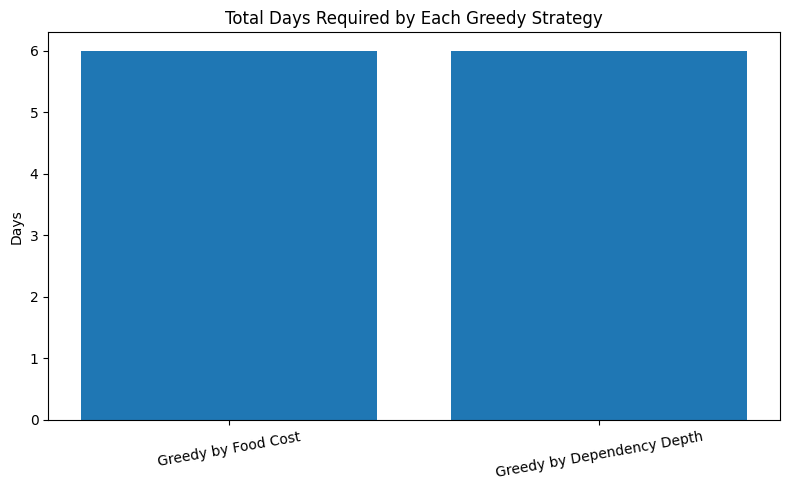

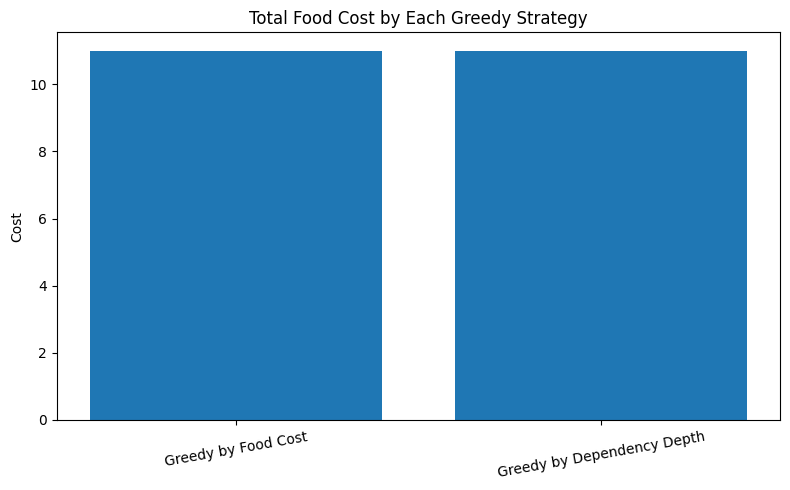

In [ ]:
import matplotlib.pyplot as plt

summary_df = pd.DataFrame({
    "Strategy": ["Greedy by Food Cost", "Greedy by Dependency Depth"],
    "Total Days": [total_days_food, total_days_depth],
    "Total Cost": [total_cost_food, total_cost_depth]
})

display(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df["Strategy"], summary_df["Total Days"])
plt.title("Total Days Required by Each Greedy Strategy")
plt.ylabel("Days")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["Strategy"], summary_df["Total Cost"])
plt.title("Total Food Cost by Each Greedy Strategy")
plt.ylabel("Cost")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

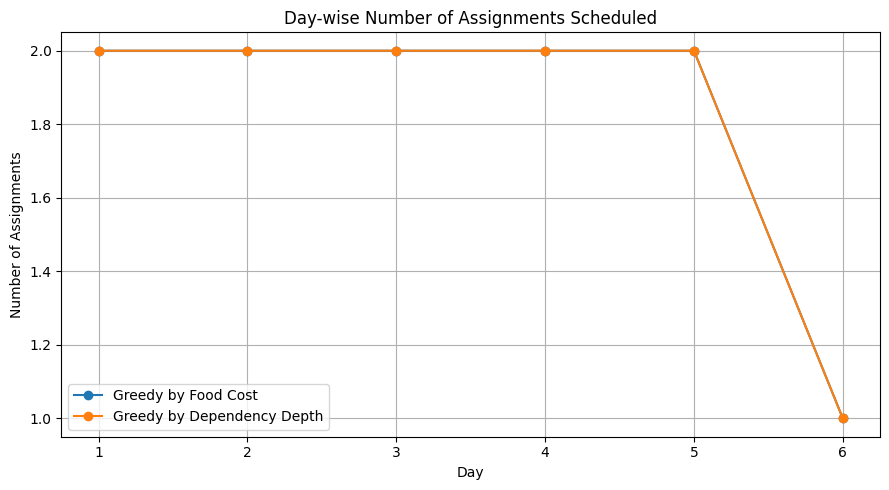

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_food["Day"], df_food["Num_Assignments"], marker='o', label="Greedy by Food Cost")
plt.plot(df_depth["Day"], df_depth["Num_Assignments"], marker='o', label="Greedy by Dependency Depth")
plt.title("Day-wise Number of Assignments Scheduled")
plt.xlabel("Day")
plt.ylabel("Number of Assignments")
plt.xticks(df_food["Day"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

,Greedy by Food Cost,Greedy by Dependency Depth
TC,6,6
DF,2,2
PM,2,2
GJ,1,1


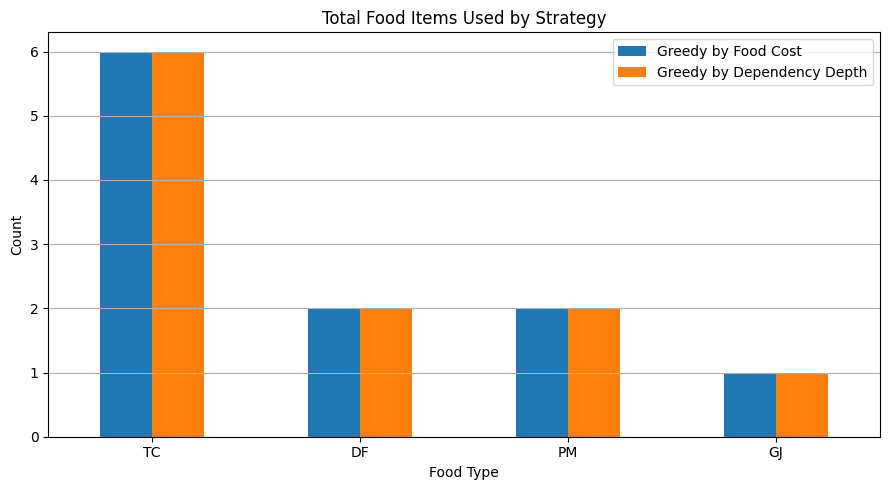

In [ ]:
food_cols = [col for col in df_food.columns if col.startswith("Food_")]

food_totals_food = df_food[food_cols].sum()
food_totals_depth = df_depth[food_cols].sum()

food_compare = pd.DataFrame({
    "Greedy by Food Cost": food_totals_food.values,
    "Greedy by Dependency Depth": food_totals_depth.values
}, index=[col.replace("Food_", "") for col in food_cols])

display(food_compare)

food_compare.plot(kind="bar", figsize=(9, 5))
plt.title("Total Food Items Used by Strategy")
plt.xlabel("Food Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_362/1380923445.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


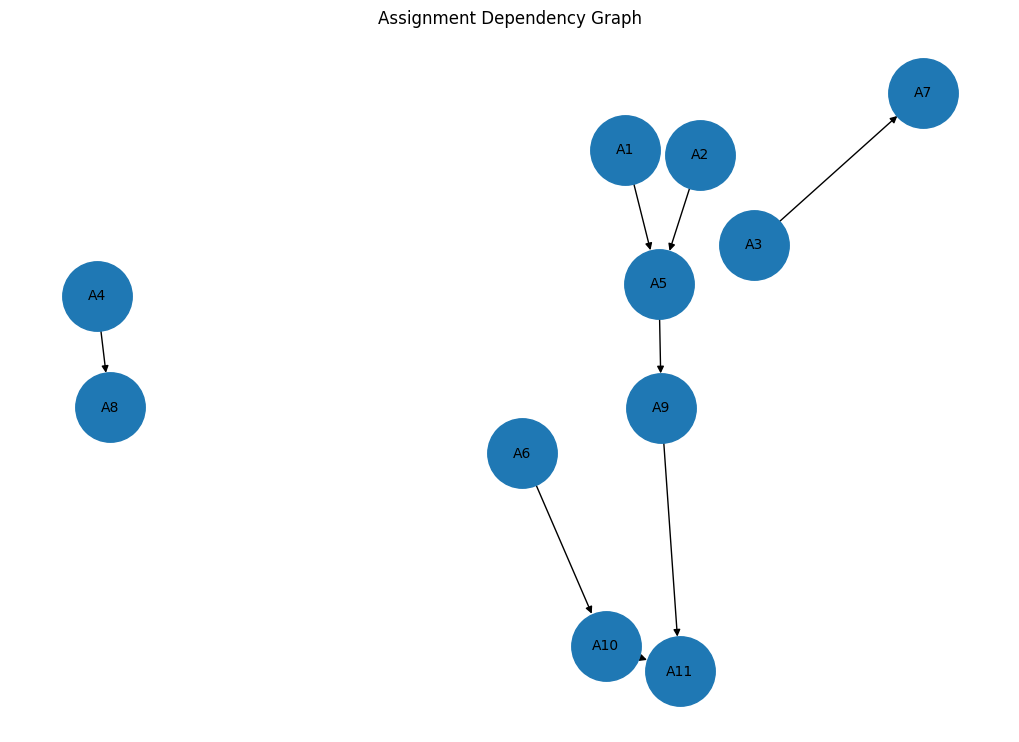

In [ ]:
import networkx as nx

def build_assignment_dependency_graph(data):
    G = nx.DiGraph()
    assignments = data["assignments"]

    outcome_to_assignment = {}
    for aid, info in assignments.items():
        outcome_to_assignment[info["outcome"]] = aid

    for aid in assignments:
        G.add_node(f"A{aid}")

    for aid, info in assignments.items():
        for prereq in info["prereqs"]:
            if prereq in outcome_to_assignment:
                parent = outcome_to_assignment[prereq]
                G.add_edge(f"A{parent}", f"A{aid}")

    return G

G_dep = build_assignment_dependency_graph(data)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_dep, seed=42)
nx.draw(
    G_dep, pos,
    with_labels=True,
    node_size=2500,
    font_size=10,
    arrows=True
)
plt.title("Assignment Dependency Graph")
plt.tight_layout()
plt.show()

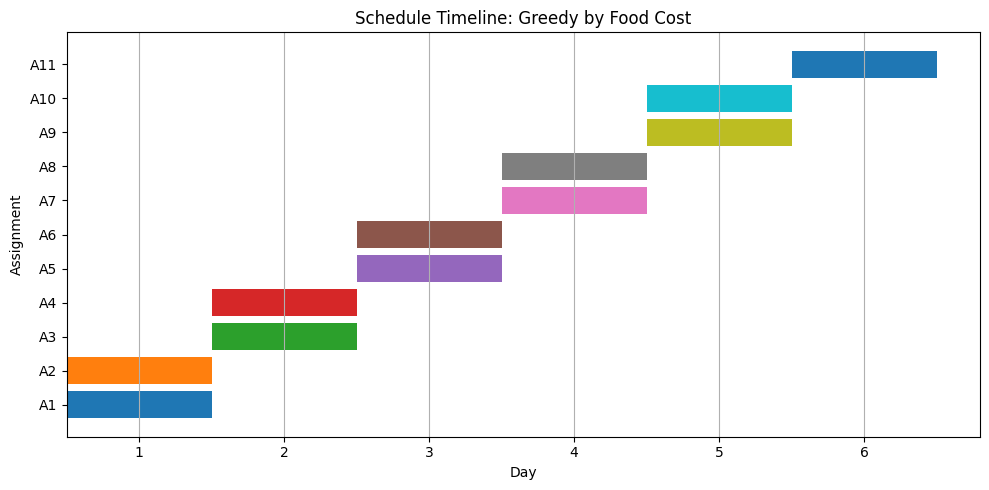

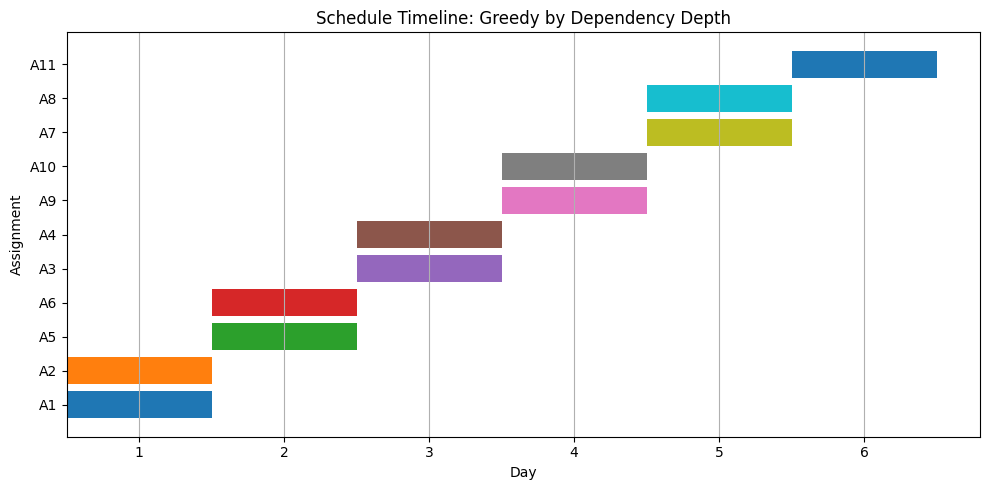

In [ ]:
def plot_schedule_timeline(df, title):
    plt.figure(figsize=(10, 5))
    for _, row in df.iterrows():
        tasks = row["Assignments"].split(", ")
        for task in tasks:
            task_num = int(task[1:])
            plt.barh(task, 1, left=row["Day"]-0.5)

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Assignment")
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

plot_schedule_timeline(df_food, "Schedule Timeline: Greedy by Food Cost")
plot_schedule_timeline(df_depth, "Schedule Timeline: Greedy by Dependency Depth")

# **TASK 2**

In [ ]:
import heapq
from itertools import combinations
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def generate_day_choices(avail, g):
    choices = []
    max_size = min(g, len(avail))
    for r in range(1, max_size + 1):
        for combo in combinations(avail, r):
            choices.append(tuple(sorted(combo)))
    return choices

In [ ]:
def heuristic(data, completed):
    remaining = len(data["assignments"]) - len(completed)
    min_food_cost = min(data["food_cost"].values())
    return remaining * min_food_cost

def apply_day(data, completed, available_resources, chosen):
    new_completed = set(completed)
    new_resources = set(available_resources)

    for aid in chosen:
        new_completed.add(aid)
        new_resources.add(data["assignments"][aid]["outcome"])

    menu_counter, cost_today = day_menu_cost(chosen, data)
    return frozenset(new_completed), frozenset(new_resources), menu_counter, cost_today

In [ ]:
def astar_optimal_schedule(data):
    assignments = data["assignments"]
    start_completed = frozenset()
    start_resources = frozenset(data["initial_inputs"])

    start_g = 0
    start_h = heuristic(data, start_completed)
    start_f = start_g + start_h

    pq = []
    state_id = 0

    heapq.heappush(
        pq,
        (
            start_f,
            start_g,
            0,
            state_id,
            start_completed,
            start_resources,
            []
        )
    )

    best_cost = {}
    best_cost[(start_completed, start_resources)] = 0

    states_explored = 0

    while pq:
        f_val, g_val, days_used, _, completed, resources, schedule = heapq.heappop(pq)
        states_explored += 1

        if len(completed) == len(assignments):
            return {
                "schedule": schedule,
                "total_days": days_used,
                "total_cost": g_val,
                "states_explored": states_explored
            }

        avail = available_assignments(data, completed, resources)

        if not avail:
            continue

        day_choices = generate_day_choices(avail, data["group_size"])

        for chosen in day_choices:
            new_completed, new_resources, menu_counter, cost_today = apply_day(
                data, completed, resources, chosen
            )

            new_g = g_val + cost_today
            new_h = heuristic(data, new_completed)
            new_f = new_g + new_h
            new_days = days_used + 1

            state_key = (new_completed, new_resources)

            if state_key not in best_cost or new_g < best_cost[state_key]:
                best_cost[state_key] = new_g
                state_id += 1

                new_schedule = schedule + [{
                    "day": new_days,
                    "assignments": list(chosen),
                    "menu": menu_counter,
                    "cost": cost_today
                }]

                heapq.heappush(
                    pq,
                    (
                        new_f,
                        new_g,
                        new_days,
                        state_id,
                        new_completed,
                        new_resources,
                        new_schedule
                    )
                )

    return None

In [ ]:
sample_input = """
% Comments
% Cost <food-item> <value>
C TC 1
C DF 1
C PM 1
C GJ 1
% Group size
G 2
% Inputs - books / notes. It ends with -1
I 1 2 3 4 5 6 -1
% Outputs - final outcome. It ends with -1
O 13 14 17 -1
% Assignment dependency list
% A <id> <input1> <input2> <outcome> <Food-name>
A 1 1 3 7 TC
A 2 4 2 8 TC
A 3 1 3 9 TC
A 4 2 3 10 PM
A 5 7 8 11 TC
A 6 4 6 12 TC
A 7 6 9 13 PM
A 8 10 5 14 GJ
A 9 1 11 15 DF
A 10 3 12 16 TC
A 11 15 16 17 DF
"""

data = parse_input(sample_input)
astar_result = astar_optimal_schedule(data)
astar_result

{'schedule': [{'day': 1,
   'assignments': [1],
   'menu': Counter({'TC': 1}),
   'cost': 1},
  {'day': 2, 'assignments': [2, 3], 'menu': Counter({'TC': 2}), 'cost': 2},
  {'day': 3,
   'assignments': [4, 5],
   'menu': Counter({'PM': 1, 'TC': 1}),
   'cost': 2},
  {'day': 4,
   'assignments': [6, 7],
   'menu': Counter({'TC': 1, 'PM': 1}),
   'cost': 2},
  {'day': 5,
   'assignments': [9, 10],
   'menu': Counter({'DF': 1, 'TC': 1}),
   'cost': 2},
  {'day': 6,
   'assignments': [8, 11],
   'menu': Counter({'GJ': 1, 'DF': 1}),
   'cost': 2}],
 'total_days': 6,
 'total_cost': 11,
 'states_explored': 171}

In [ ]:
def format_menu(menu_counter):
    if not menu_counter:
        return "None"
    return ", ".join(f"{cnt}-{food}" for food, cnt in sorted(menu_counter.items()))

def print_astar_result(result):
    print("Optimal Schedule using A* Search")
    print("-" * 60)

    for entry in result["schedule"]:
        day = entry["day"]
        tasks = ", ".join(f"A{x}" for x in entry["assignments"])
        menu = format_menu(entry["menu"])
        print(f"Day-{day}: {tasks}    Menu: {menu}    Cost: {entry['cost']}")

    print("-" * 60)
    print(f"Total Days: {result['total_days']}")
    print(f"Total Cost: {result['total_cost']}")
    print(f"States Explored: {result['states_explored']}")

print_astar_result(astar_result)

Optimal Schedule using A* Search
------------------------------------------------------------
Day-1: A1    Menu: 1-TC    Cost: 1
Day-2: A2, A3    Menu: 2-TC    Cost: 2
Day-3: A4, A5    Menu: 1-PM, 1-TC    Cost: 2
Day-4: A6, A7    Menu: 1-PM, 1-TC    Cost: 2
Day-5: A9, A10    Menu: 1-DF, 1-TC    Cost: 2
Day-6: A8, A11    Menu: 1-DF, 1-GJ    Cost: 2
------------------------------------------------------------
Total Days: 6
Total Cost: 11
States Explored: 171


In [ ]:
def greedy_food_cost_schedule(data):
    completed = set()
    resources = set(data["initial_inputs"])
    schedule = []
    total_cost = 0
    day = 1

    while len(completed) < len(data["assignments"]):
        avail = available_assignments(data, completed, resources)
        chosen = sorted(
            avail,
            key=lambda aid: (data["food_cost"][data["assignments"][aid]["food"]], aid)
        )[:data["group_size"]]

        for aid in chosen:
            completed.add(aid)
            resources.add(data["assignments"][aid]["outcome"])

        menu_counter, cost_today = day_menu_cost(chosen, data)
        total_cost += cost_today

        schedule.append({
            "day": day,
            "assignments": chosen,
            "menu": menu_counter,
            "cost": cost_today
        })
        day += 1

    return {
        "schedule": schedule,
        "total_days": len(schedule),
        "total_cost": total_cost
    }

greedy_result = greedy_food_cost_schedule(data)

print("Greedy Total Days:", greedy_result["total_days"])
print("Greedy Total Cost:", greedy_result["total_cost"])
print("A* Total Days:", astar_result["total_days"])
print("A* Total Cost:", astar_result["total_cost"])
print("Cost Difference (Greedy - A*):", greedy_result["total_cost"] - astar_result["total_cost"])
print("Day Difference (Greedy - A*):", greedy_result["total_days"] - astar_result["total_days"])

Greedy Total Days: 6
Greedy Total Cost: 11
A* Total Days: 6
A* Total Cost: 11
Cost Difference (Greedy - A*): 0
Day Difference (Greedy - A*): 0


In [ ]:
def schedule_to_df(result, strategy_name):
    rows = []
    for entry in result["schedule"]:
        rows.append({
            "Strategy": strategy_name,
            "Day": entry["day"],
            "Assignments": ", ".join(f"A{x}" for x in entry["assignments"]),
            "Num_Assignments": len(entry["assignments"]),
            "Menu": format_menu(entry["menu"]),
            "Daily_Cost": entry["cost"]
        })
    return pd.DataFrame(rows)

df_astar = schedule_to_df(astar_result, "A*")
df_greedy = schedule_to_df(greedy_result, "Greedy")

display(df_astar)
display(df_greedy)

,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost
0,A*,1,A1,1,1-TC,1
1,A*,2,"A2, A3",2,2-TC,2
2,A*,3,"A4, A5",2,"1-PM, 1-TC",2
3,A*,4,"A6, A7",2,"1-PM, 1-TC",2
4,A*,5,"A9, A10",2,"1-DF, 1-TC",2
5,A*,6,"A8, A11",2,"1-DF, 1-GJ",2


,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost
0,Greedy,1,"A1, A2",2,2-TC,2
1,Greedy,2,"A3, A4",2,"1-PM, 1-TC",2
2,Greedy,3,"A5, A6",2,2-TC,2
3,Greedy,4,"A7, A8",2,"1-GJ, 1-PM",2
4,Greedy,5,"A9, A10",2,"1-DF, 1-TC",2
5,Greedy,6,A11,1,1-DF,1


,Method,Total Days,Total Cost
0,Greedy,6,11
1,A*,6,11


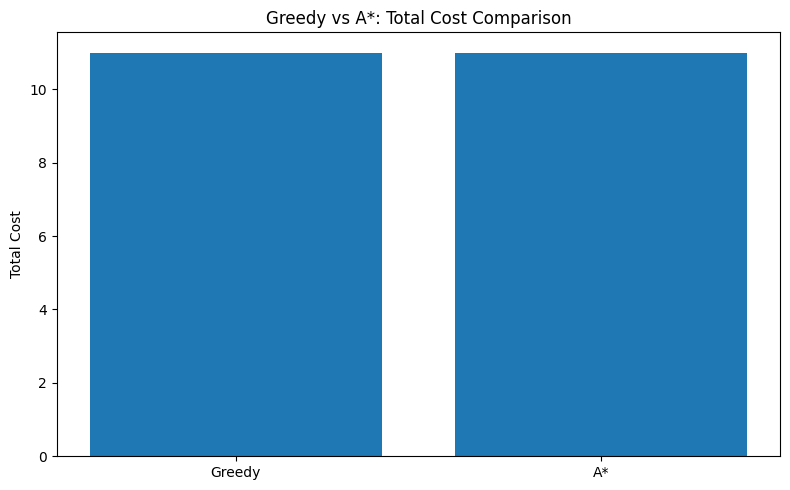

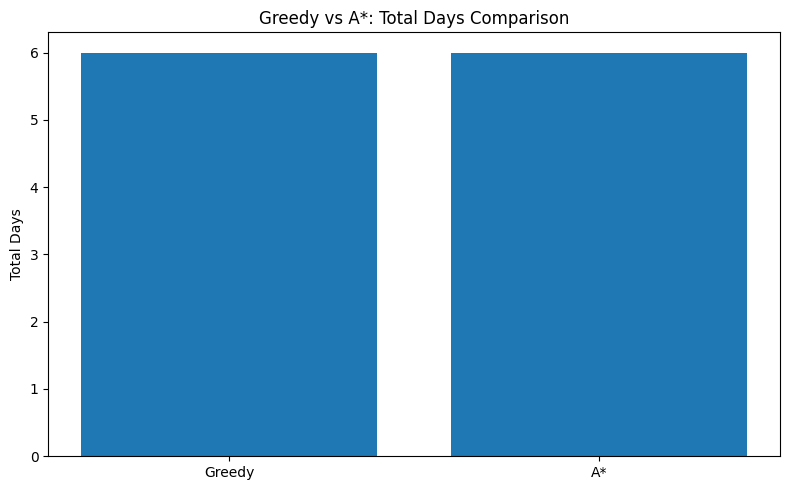

In [ ]:
compare_df = pd.DataFrame({
    "Method": ["Greedy", "A*"],
    "Total Days": [greedy_result["total_days"], astar_result["total_days"]],
    "Total Cost": [greedy_result["total_cost"], astar_result["total_cost"]]
})

display(compare_df)

plt.figure(figsize=(8, 5))
plt.bar(compare_df["Method"], compare_df["Total Cost"])
plt.title("Greedy vs A*: Total Cost Comparison")
plt.ylabel("Total Cost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(compare_df["Method"], compare_df["Total Days"])
plt.title("Greedy vs A*: Total Days Comparison")
plt.ylabel("Total Days")
plt.tight_layout()
plt.show()

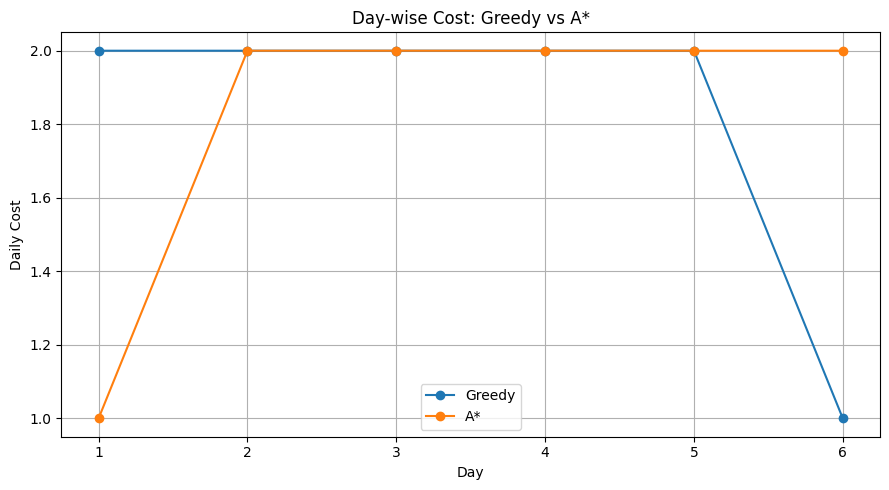

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_greedy["Day"], df_greedy["Daily_Cost"], marker='o', label="Greedy")
plt.plot(df_astar["Day"], df_astar["Daily_Cost"], marker='o', label="A*")
plt.title("Day-wise Cost: Greedy vs A*")
plt.xlabel("Day")
plt.ylabel("Daily Cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()